In [6]:
import glob
import os
import pandas as pd
import numpy as np
from specdal import Spectrum
import matplotlib.pyplot as plt
import math


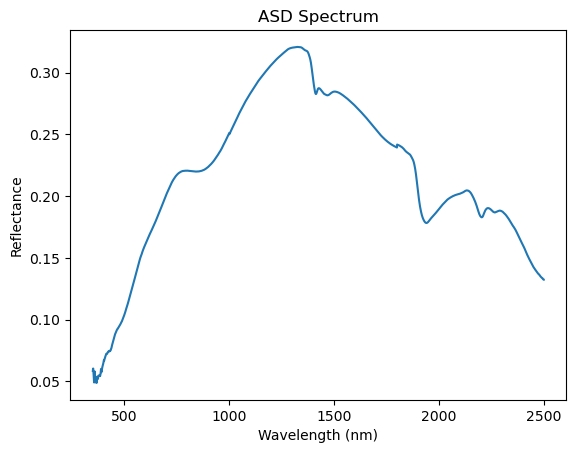

In [ ]:

# Path to the VNIR-SWIR data folder
data_folder = 'VNIR_SWIR_LG_2024/VNIR_SWIR_LG2_024/'

# Collect all .asd files
files = sorted(glob.glob(os.path.join(data_folder, '*.asd')))

# Initialize an empty list to hold DataFrames
dfs = []

# Loop over all files
for f in files:
    try:
        # Load the spectrum
        spec = Spectrum(filepath=f)
        # Get the filename without extension for column name
        name = os.path.basename(f).replace('.asd', '')
        # Create a DataFrame from the measurement (wavelengths as index, reflectance as column)
        df = spec.measurement.to_frame(name=name)
        dfs.append(df)
    except Exception as e:
        print(f"Error loading {f}: {e}")

# Combine all DataFrames into one, aligned by wavelength index
if dfs:
    alldata = pd.concat(dfs, axis=1)
    # Compute average reflectance
    alldata['Avg refl'] = alldata.mean(axis=1)
    print("Data loaded successfully. Shape:", alldata.shape)
    print(alldata.head())
else:
    print("No valid files loaded.")

# Example plot of average spectrum
plt.plot(alldata.index, alldata['Avg refl'])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Average ASD Spectrum")
plt.show()